In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.neural_network import MLPClassifier
import time

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, precision_recall_curve, auc)


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("application_train.csv")

print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [9]:
df['TARGET'].value_counts(normalize=True) 

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [10]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# How many columns exceed certain thresholds?
print("Columns with >50% missing:", (missing_pct > 50).sum())
print("Columns with >40% missing:", (missing_pct > 40).sum())
print("Columns with 0% missing:", (missing_pct == 0).sum())

Columns with >50% missing: 41
Columns with >40% missing: 49
Columns with 0% missing: 55


In [ ]:
# Drop columns with >40% missing
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
df = df.drop(columns=cols_to_drop)

df = df.drop(columns=['SK_ID_CURR'])

remaining_missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(remaining_missing[remaining_missing > 0])

OCCUPATION_TYPE               31.345545
EXT_SOURCE_3                  19.825307
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
NAME_TYPE_SUITE                0.420148
OBS_30_CNT_SOCIAL_CIRCLE       0.332021
DEF_30_CNT_SOCIAL_CIRCLE       0.332021
OBS_60_CNT_SOCIAL_CIRCLE       0.332021
DEF_60_CNT_SOCIAL_CIRCLE       0.332021
EXT_SOURCE_2                   0.214626
AMT_GOODS_PRICE                0.090403
AMT_ANNUITY                    0.003902
CNT_FAM_MEMBERS                0.000650
DAYS_LAST_PHONE_CHANGE         0.000325
dtype: float64


In [ ]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {len(num_cols)}")

Categorical columns (12): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']
Numeric columns (59): 59


In [13]:
for col in cat_cols:
    print(f"{col}: {X[col].nunique()} unique values")

NAME_CONTRACT_TYPE: 2 unique values
CODE_GENDER: 3 unique values
FLAG_OWN_CAR: 2 unique values
FLAG_OWN_REALTY: 2 unique values
NAME_TYPE_SUITE: 7 unique values
NAME_INCOME_TYPE: 8 unique values
NAME_EDUCATION_TYPE: 5 unique values
NAME_FAMILY_STATUS: 6 unique values
NAME_HOUSING_TYPE: 6 unique values
OCCUPATION_TYPE: 18 unique values
WEEKDAY_APPR_PROCESS_START: 7 unique values
ORGANIZATION_TYPE: 58 unique values


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")

Train: (215257, 71), Val: (46127, 71), Test: (46127, 71)
Train target distribution:
TARGET
0    0.919273
1    0.080727
Name: proportion, dtype: float64


In [ ]:
num_medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(num_medians)
X_val[num_cols] = X_val[num_cols].fillna(num_medians)
X_test[num_cols] = X_test[num_cols].fillna(num_medians)

cat_modes = X_train[cat_cols].mode().iloc[0]
X_train[cat_cols] = X_train[cat_cols].fillna(cat_modes)
X_val[cat_cols] = X_val[cat_cols].fillna(cat_modes)
X_test[cat_cols] = X_test[cat_cols].fillna(cat_modes)

le = LabelEncoder()
X_train['ORGANIZATION_TYPE'] = le.fit_transform(X_train['ORGANIZATION_TYPE'])
X_val['ORGANIZATION_TYPE'] = le.transform(X_val['ORGANIZATION_TYPE'])
X_test['ORGANIZATION_TYPE'] = le.transform(X_test['ORGANIZATION_TYPE'])

ohe_cols = [c for c in cat_cols if c != 'ORGANIZATION_TYPE']

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=ohe_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=ohe_cols, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Final shape - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Any missing left? {X_train.isnull().sum().sum()}")

Final shape - Train: (215257, 115), Val: (46127, 115), Test: (46127, 115)
Any missing left? 0


In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), 
    columns=X_val.columns, 
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

print("Scaled train mean (first 5 cols):", X_train_scaled.iloc[:, :5].mean().values)
print("Scaled train std (first 5 cols):", X_train_scaled.iloc[:, :5].std().values)

Scaled train mean (first 5 cols): [ 2.57965663e-17  1.27749119e-16  1.16488909e-16 -9.57592309e-17
 -2.26772119e-17]
Scaled train std (first 5 cols): [1.00000232 1.00000232 1.00000232 1.00000232 1.00000232]


## 2. Gradient Boosted Tree (GBDT)

In [17]:
!pip install xgboost

In [18]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score


In [19]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    scale_pos_weight=11.3,  # handle class imbalance (~0.919/0.081)
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=50
)

# Train with eval_set to monitor train vs validation loss
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50  # print every 50 rounds
)

# Check performance on validation set
y_val_pred = xgb_model.predict(X_val)
y_val_prob = xgb_model.predict_proba(X_val)[:, 1]

print("\nValidation Results:")
print(classification_report(y_val, y_val_pred))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob):.4f}")

[0]	validation_0-logloss:0.67568	validation_1-logloss:0.67588
[50]	validation_0-logloss:0.56410	validation_1-logloss:0.57339
[100]	validation_0-logloss:0.54131	validation_1-logloss:0.55765
[150]	validation_0-logloss:0.52401	validation_1-logloss:0.54606
[200]	validation_0-logloss:0.50708	validation_1-logloss:0.53485
[250]	validation_0-logloss:0.49326	validation_1-logloss:0.52541
[300]	validation_0-logloss:0.47911	validation_1-logloss:0.51611
[350]	validation_0-logloss:0.46526	validation_1-logloss:0.50695
[400]	validation_0-logloss:0.45233	validation_1-logloss:0.49882
[450]	validation_0-logloss:0.43964	validation_1-logloss:0.49058
[499]	validation_0-logloss:0.42709	validation_1-logloss:0.48293

Validation Results:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86     42403
           1       0.18      0.56      0.28      3724

    accuracy                           0.76     46127
   macro avg       0.57      0.67      0.57     46127
weight

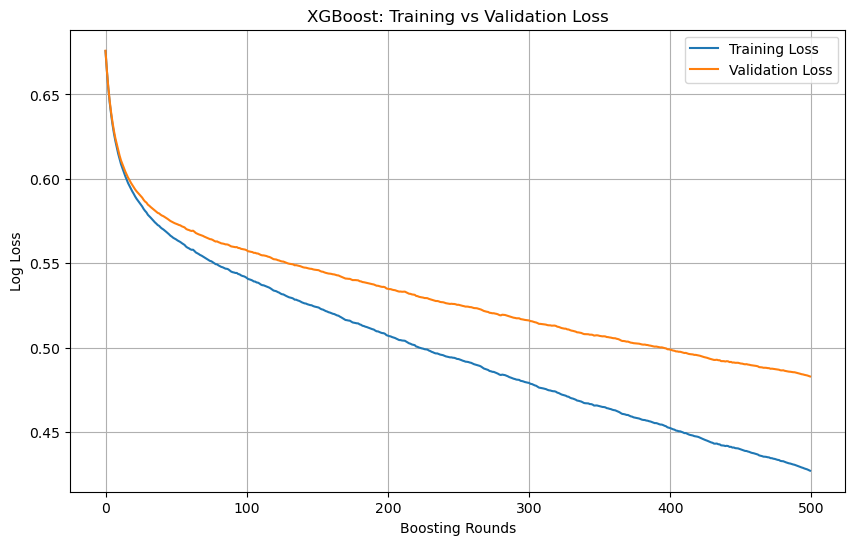

In [20]:
import matplotlib.pyplot as plt

results = xgb_model.evals_result()

plt.figure(figsize=(10, 6))
plt.plot(results['validation_0']['logloss'], label='Training Loss')
plt.plot(results['validation_1']['logloss'], label='Validation Loss')
plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('XGBoost: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

learning rate comparison


Training with learning_rate=0.01...
  Best iteration: 499

Training with learning_rate=0.1...
  Best iteration: 499

Training with learning_rate=0.3...
  Best iteration: 499


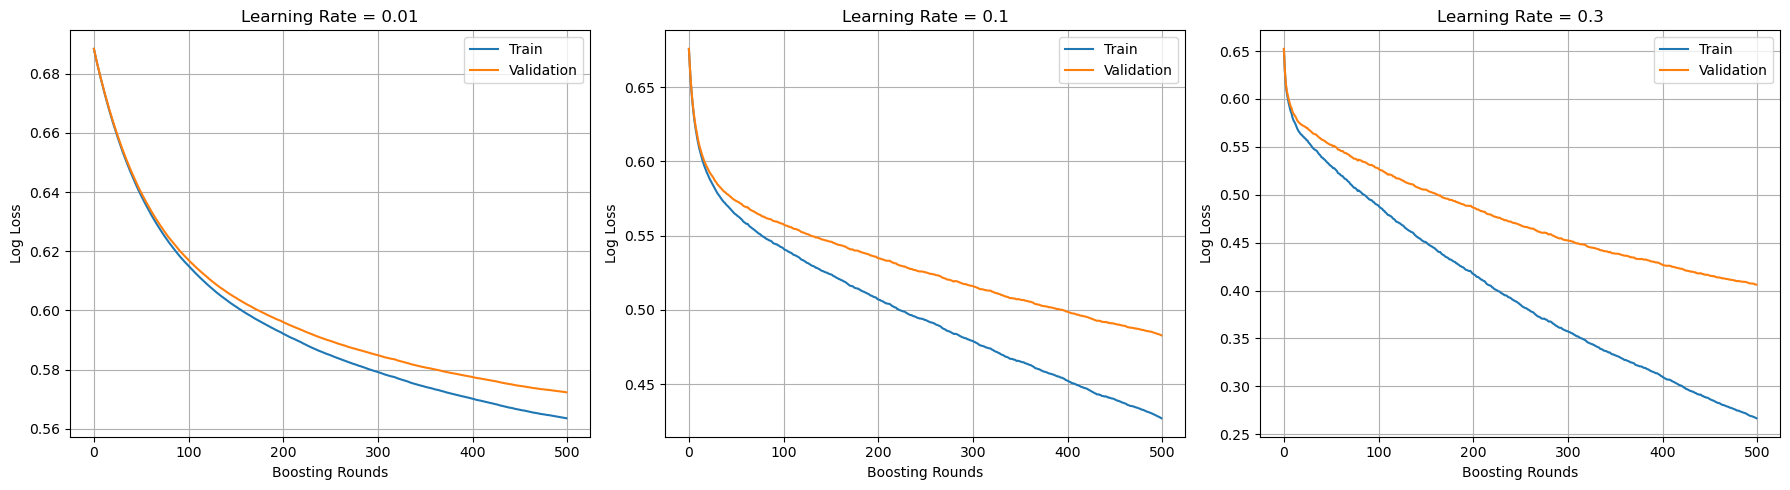

In [21]:
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

for lr in learning_rates:
    print(f"\nTraining with learning_rate={lr}...")
    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=lr,
        max_depth=6,
        subsample=0.8,
        scale_pos_weight=11.3,
        eval_metric='logloss',
        random_state=42,
        early_stopping_rounds=50
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    lr_results[lr] = model.evals_result()
    print(f"  Best iteration: {model.best_iteration}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, lr in enumerate(learning_rates):
    axes[i].plot(lr_results[lr]['validation_0']['logloss'], label='Train')
    axes[i].plot(lr_results[lr]['validation_1']['logloss'], label='Validation')
    axes[i].set_title(f'Learning Rate = {lr}')
    axes[i].set_xlabel('Boosting Rounds')
    axes[i].set_ylabel('Log Loss')
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

Feature importance

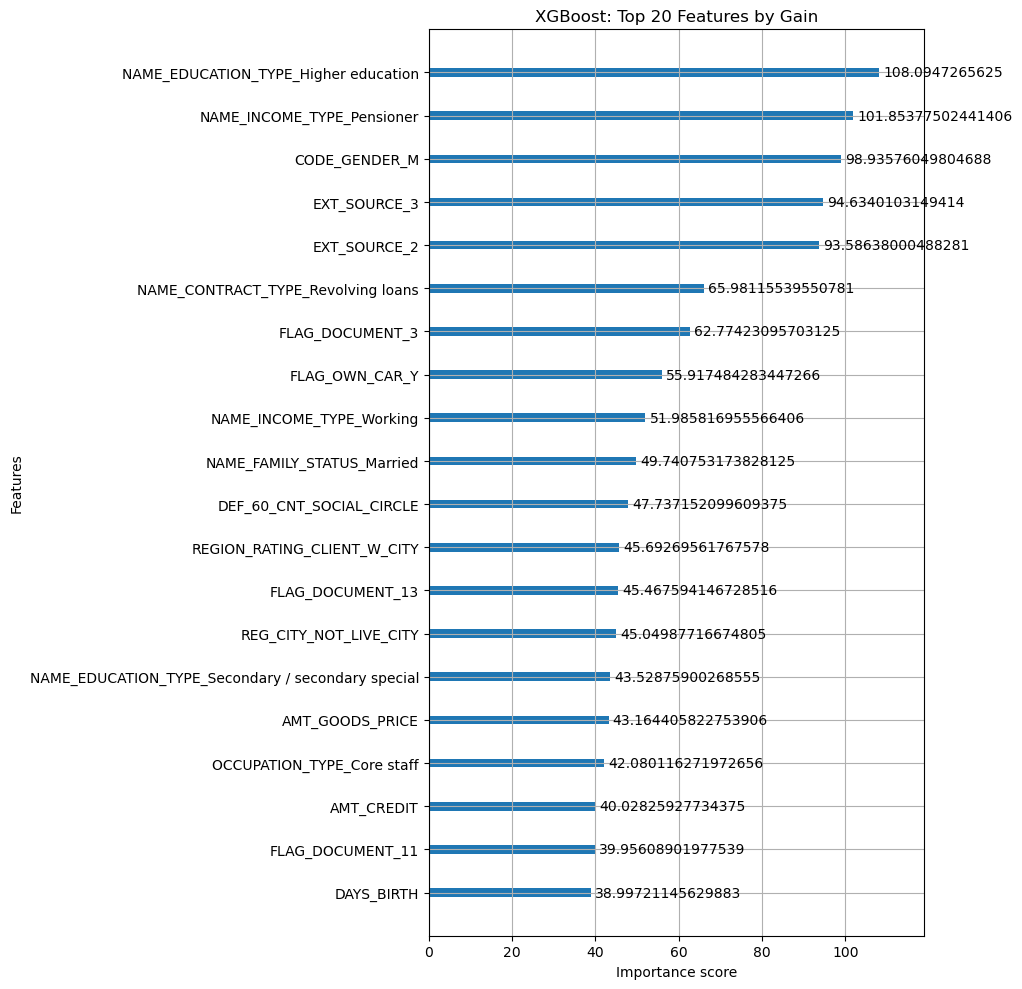

In [31]:
from xgboost import plot_importance

# Use the baseline model (lr=0.1)
fig, ax = plt.subplots(figsize=(10, 10))
plot_importance(xgb_model, max_num_features=20, ax=ax, importance_type='gain')
ax.set_title('XGBoost: Top 20 Features by Gain')
plt.tight_layout()
plt.show()

In [ ]:
param_dist = {
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=11.3,
        eval_metric='logloss',
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,           # try 20 random combinations
    scoring='roc_auc',   
    cv=3,                
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print(f"\nBest AUC: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best AUC: 0.7504
Best params: {'subsample': 0.8, 'reg_lambda': 0.01, 'reg_alpha': 10, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}


Exception ignored in: <function ResourceTracker.__del__ at 0x103051bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105041bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1078d9bc0>
Traceback (most recent call last

In [ ]:
best_xgb = xgb.XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=11.3,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=50
)

best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

# Validation metrics
from sklearn.metrics import precision_recall_curve, auc

y_val_pred = best_xgb.predict(X_val)
y_val_prob = best_xgb.predict_proba(X_val)[:, 1]

print("\nTuned XGBoost - Validation Results:")
print(classification_report(y_val, y_val_pred))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob):.4f}")

# AUC-PR (important for imbalanced data)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_prob)
auc_pr = auc(recall_vals, precision_vals)
print(f"AUC-PR: {auc_pr:.4f}")

[0]	validation_0-logloss:0.68442	validation_1-logloss:0.68439
[50]	validation_0-logloss:0.61087	validation_1-logloss:0.61151
[100]	validation_0-logloss:0.59737	validation_1-logloss:0.59843
[150]	validation_0-logloss:0.59053	validation_1-logloss:0.59202
[200]	validation_0-logloss:0.58631	validation_1-logloss:0.58838
[250]	validation_0-logloss:0.58309	validation_1-logloss:0.58562
[300]	validation_0-logloss:0.58089	validation_1-logloss:0.58403
[350]	validation_0-logloss:0.57894	validation_1-logloss:0.58249
[400]	validation_0-logloss:0.57752	validation_1-logloss:0.58147
[450]	validation_0-logloss:0.57508	validation_1-logloss:0.57949
[499]	validation_0-logloss:0.57421	validation_1-logloss:0.57912

Tuned XGBoost - Validation Results:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     42403
           1       0.16      0.67      0.26      3724

    accuracy                           0.69     46127
   macro avg       0.56      0.68      0.53 

## 3. Multi-Layer Perceptron (MLP)

In [36]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

start_time = time.time()
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time

y_val_pred_mlp = mlp_model.predict(X_val_scaled)
y_val_prob_mlp = mlp_model.predict_proba(X_val_scaled)[:, 1]

print(f"\nTraining time: {mlp_train_time:.2f} seconds")
print(f"Iterations completed: {mlp_model.n_iter_}")
print("\nMLP Validation Results:")
print(classification_report(y_val, y_val_pred_mlp))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob_mlp):.4f}")

Iteration 1, loss = 0.26288559
Validation score: 0.919214
Iteration 2, loss = 0.25208565
Validation score: 0.919260
Iteration 3, loss = 0.24919068
Validation score: 0.918982
Iteration 4, loss = 0.24723001
Validation score: 0.918889
Iteration 5, loss = 0.24543296
Validation score: 0.918564
Iteration 6, loss = 0.24306695
Validation score: 0.918796
Iteration 7, loss = 0.24093193
Validation score: 0.918424
Iteration 8, loss = 0.23876502
Validation score: 0.917309
Iteration 9, loss = 0.23576730
Validation score: 0.917031
Iteration 10, loss = 0.23319024
Validation score: 0.915126
Iteration 11, loss = 0.23069455
Validation score: 0.914801
Iteration 12, loss = 0.22817520
Validation score: 0.914429
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

Training time: 24.00 seconds
Iterations completed: 12

MLP Validation Results:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       

In [37]:
print("Class 1 predictions:", (y_val_pred_mlp == 1).sum())
print("Total predictions:", len(y_val_pred_mlp))

Class 1 predictions: 3
Total predictions: 46127


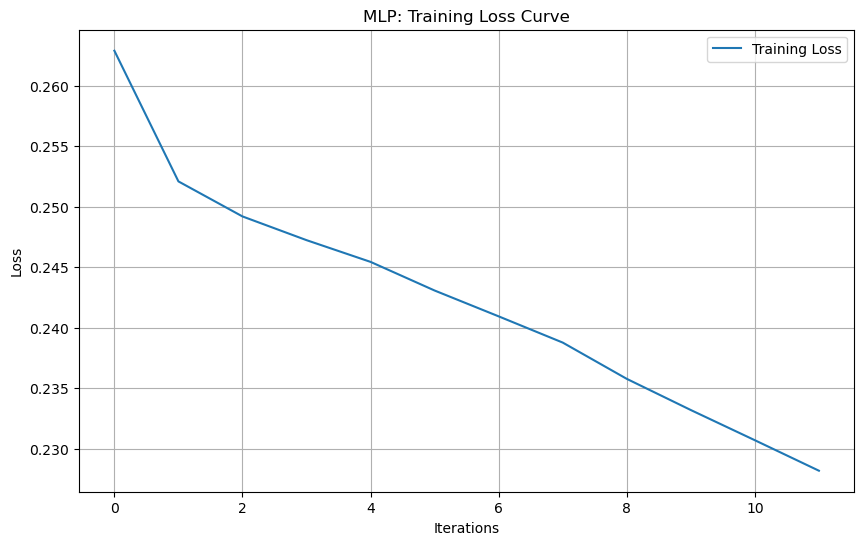

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP: Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,    
    verbose=True
)

start_time = time.time()
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time

y_val_prob_mlp = mlp_model.predict_proba(X_val_scaled)[:, 1]
from sklearn.metrics import precision_recall_curve, auc, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_prob_mlp)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[f1_scores.argmax()]
print(f"\nBest threshold: {best_threshold:.4f}")



Iteration 1, loss = 0.26288559
Validation score: 0.919214
Iteration 2, loss = 0.25208565
Validation score: 0.919260
Iteration 3, loss = 0.24919068
Validation score: 0.918982
Iteration 4, loss = 0.24723001
Validation score: 0.918889
Iteration 5, loss = 0.24543296
Validation score: 0.918564
Iteration 6, loss = 0.24306695
Validation score: 0.918796
Iteration 7, loss = 0.24093193
Validation score: 0.918424
Iteration 8, loss = 0.23876502
Validation score: 0.917309
Iteration 9, loss = 0.23576730
Validation score: 0.917031
Iteration 10, loss = 0.23319024
Validation score: 0.915126
Iteration 11, loss = 0.23069455
Validation score: 0.914801
Iteration 12, loss = 0.22817520
Validation score: 0.914429
Iteration 13, loss = 0.22565109
Validation score: 0.914661
Iteration 14, loss = 0.22320911
Validation score: 0.912710
Iteration 15, loss = 0.22091378
Validation score: 0.913779
Iteration 16, loss = 0.21851768
Validation score: 0.912664
Iteration 17, loss = 0.21631426
Validation score: 0.911735
Iterat

In [45]:
# Apply the optimized threshold
y_val_pred_mlp = (y_val_prob_mlp >= best_threshold).astype(int)

print(f"Training time: {mlp_train_time:.2f} seconds")
print(f"Iterations completed: {mlp_model.n_iter_}")
print(f"Class 1 predictions: {(y_val_pred_mlp == 1).sum()}")
print("\nMLP Validation Results:")
print(classification_report(y_val, y_val_pred_mlp))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob_mlp):.4f}")

auc_pr = auc(recalls, precisions)
print(f"AUC-PR: {auc_pr:.4f}")

Training time: 77.34 seconds
Iterations completed: 32
Class 1 predictions: 6968

MLP Validation Results:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91     42403
           1       0.22      0.41      0.28      3724

    accuracy                           0.83     46127
   macro avg       0.58      0.64      0.60     46127
weighted avg       0.89      0.83      0.86     46127

AUC-ROC: 0.7341
AUC-PR: 0.2124



Training (64,)...
  AUC-ROC: 0.7299, Iterations: 32

Training (128, 64)...
  AUC-ROC: 0.7341, Iterations: 32

Training (256, 128, 64)...
  AUC-ROC: 0.7369, Iterations: 32


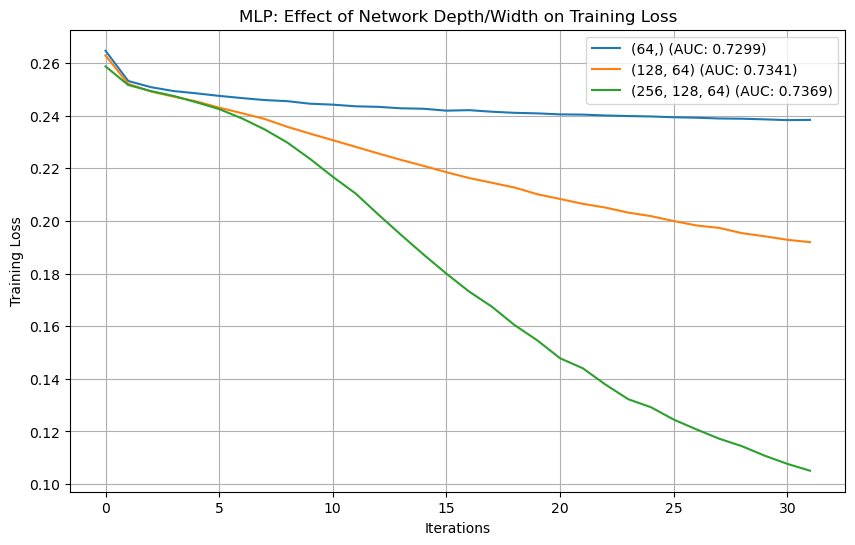

In [40]:
architectures = {
    '(64,)': (64,),
    '(128, 64)': (128, 64),
    '(256, 128, 64)': (256, 128, 64)
}

arch_results = {}

for name, layers in architectures.items():
    print(f"\nTraining {name}...")
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    
    y_prob = model.predict_proba(X_val_scaled)[:, 1]
    auc_roc = roc_auc_score(y_val, y_prob)
    
    arch_results[name] = {
        'auc_roc': auc_roc,
        'iterations': model.n_iter_,
        'loss_curve': model.loss_curve_
    }
    print(f"  AUC-ROC: {auc_roc:.4f}, Iterations: {model.n_iter_}")

# Plot loss curves for all architectures
plt.figure(figsize=(10, 6))
for name, res in arch_results.items():
    plt.plot(res['loss_curve'], label=f"{name} (AUC: {res['auc_roc']:.4f})")
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.title('MLP: Effect of Network Depth/Width on Training Loss')
plt.legend()
plt.grid(True)
plt.show()


Training with activation=relu...
  AUC-ROC: 0.7341, Iterations: 32

Training with activation=tanh...
  AUC-ROC: 0.7317, Iterations: 33

Training with learning_rate_init=0.001...
  AUC-ROC: 0.7341, Iterations: 32

Training with learning_rate_init=0.01...
  AUC-ROC: 0.7310, Iterations: 32

Training with learning_rate_init=0.1...
  AUC-ROC: 0.5858, Iterations: 32


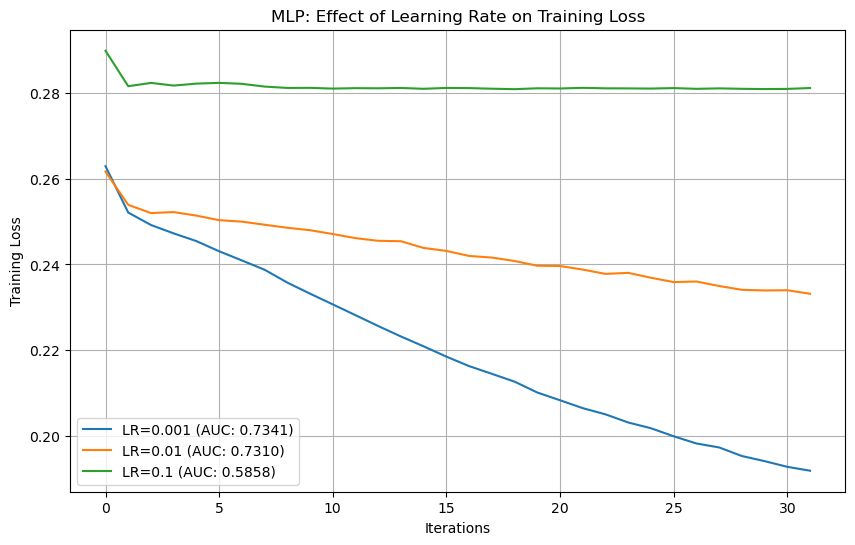

In [ ]:
activations = ['relu', 'tanh']
act_results = {}

for act in activations:
    print(f"\nTraining with activation={act}...")
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]
    auc_roc = roc_auc_score(y_val, y_prob)
    act_results[act] = {'auc': auc_roc, 'iters': model.n_iter_}
    print(f"  AUC-ROC: {auc_roc:.4f}, Iterations: {model.n_iter_}")

learning_rates_mlp = [0.001, 0.01, 0.1]
lr_results_mlp = {}

for lr in learning_rates_mlp:
    print(f"\nTraining with learning_rate_init={lr}...")
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=lr,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]
    auc_roc = roc_auc_score(y_val, y_prob)
    lr_results_mlp[lr] = {
        'auc': auc_roc,
        'iters': model.n_iter_,
        'loss_curve': model.loss_curve_
    }
    print(f"  AUC-ROC: {auc_roc:.4f}, Iterations: {model.n_iter_}")

# Plot learning rate comparison
plt.figure(figsize=(10, 6))
for lr, res in lr_results_mlp.items():
    plt.plot(res['loss_curve'], label=f"LR={lr} (AUC: {res['auc']:.4f})")
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.title('MLP: Effect of Learning Rate on Training Loss')
plt.legend()
plt.grid(True)
plt.show()

## 4. GBDT vs MLP Comparison

In [ ]:
start_xgb = time.time()
y_test_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
xgb_inference_time = time.time() - start_xgb
y_test_pred_xgb = best_xgb.predict(X_test)


best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    verbose=False
)

start_mlp_train = time.time()
best_mlp.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_mlp_train

start_mlp = time.time()
y_test_prob_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]
mlp_inference_time = time.time() - start_mlp

precisions_mlp, recalls_mlp, thresholds_mlp = precision_recall_curve(y_val, 
    best_mlp.predict_proba(X_val_scaled)[:, 1])
f1_scores_mlp = 2 * (precisions_mlp * recalls_mlp) / (precisions_mlp + recalls_mlp + 1e-8)
best_threshold = thresholds_mlp[f1_scores_mlp.argmax()]
y_test_pred_mlp = (y_test_prob_mlp >= best_threshold).astype(int)

def calc_metrics(y_true, y_pred, y_prob):
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Class 1)': precision_score(y_true, y_pred),
        'Recall (Class 1)': recall_score(y_true, y_pred),
        'F1 (Class 1)': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob),
        'AUC-PR': auc(rec, prec)
    }

xgb_metrics = calc_metrics(y_test, y_test_pred_xgb, y_test_prob_xgb)
mlp_metrics = calc_metrics(y_test, y_test_pred_mlp, y_test_prob_mlp)

comparison = pd.DataFrame({
    'XGBoost (Tuned)': xgb_metrics,
    'MLP (Best)': mlp_metrics
})
print("\n=== GBDT vs MLP: Test Set Comparison ===")
print(comparison.round(4))
print(f"\nXGBoost training time: {xgb_inference_time:.4f}s")
print(f"MLP training time: {mlp_train_time:.2f}s")


=== GBDT vs MLP: Test Set Comparison ===
                     XGBoost (Tuned)  MLP (Best)
Accuracy                      0.7009      0.8318
Precision (Class 1)           0.1673      0.2168
Recall (Class 1)              0.6799      0.4146
F1 (Class 1)                  0.2685      0.2847
AUC-ROC                       0.7573      0.7382
AUC-PR                        0.2377      0.2133

XGBoost training time: 0.0796s
MLP training time: 56.51s
